In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

csv_files = list(RAW_DATA_DIR.glob("*.csv"))
xlsx_files = list(RAW_DATA_DIR.glob("*.xlsx"))

if csv_files:
    file = csv_files[0]
    df = pd.read_csv(file)
else:
    file = xlsx_files[0]
    df = pd.read_excel(file)

print(file.name)

laramee26openBankTransactionData.xlsx


In [4]:
df.head()

,Transaction Number,Transaction Date,Transaction Type,Transaction Description,Debit Amount,Credit Amount,Balance,Category,Location City,Location Country
0,1,25/07/2022,BP,SAVE THE CHANGE,3.11,NaN,541.43,Savings,Nottingham,UK
1,2,25/07/2022,DEB,LIDL GB NOTTINGHA,15.02,NaN,544.54,Groceries,Nottingham,UK
2,3,25/07/2022,DEB,NON-GBP PURCH FEE,0.50,NaN,559.56,Others,Nottingham,UK
3,4,25/07/2022,DEB,NON-GBP TRANS FEE,0.37,NaN,560.06,Others,Nottingham,UK
4,5,25/07/2022,DEB,TRAVELIUM LLC,12.59,NaN,560.43,NaN,NaN,NaN


In [5]:
df.tail()

,Transaction Number,Transaction Date,Transaction Type,Transaction Description,Debit Amount,Credit Amount,Balance,Category,Location City,Location Country
6562,6563,28/07/2015,DEB,Amazon Svcs Europe,5.49,NaN,7187.57,Amazon,Swansea,UK
6563,6564,28/07/2015,BP,SAVE THE CHANGE,1.10,NaN,7193.06,Savings,Swansea,UK
6564,6565,27/07/2015,DEB,Amazon UK Marketpl,6.39,NaN,7194.16,Amazon,Swansea,UK
6565,6566,27/07/2015,DEB,JS ONLINE GROCERY,316.51,NaN,7200.55,Groceries,Swansea,UK
6566,6567,27/07/2015,FPO,ALAN HOLLAND,1000.00,NaN,7517.06,Services,Swansea,UK


In [6]:
df.shape

(6567, 10)

In [7]:
df.columns.tolist()

['Transaction Number',
 'Transaction Date',
 'Transaction Type',
 'Transaction Description',
 'Debit Amount',
 'Credit Amount',
 'Balance',
 'Category',
 'Location City',
 'Location Country']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6567 entries, 0 to 6566
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction Number       6567 non-null   int64  
 1   Transaction Date         6567 non-null   object 
 2   Transaction Type         6506 non-null   str    
 3   Transaction Description  6567 non-null   object 
 4   Debit Amount             6122 non-null   float64
 5   Credit Amount            445 non-null    float64
 6   Balance                  6567 non-null   float64
 7   Category                 6543 non-null   str    
 8   Location City            5895 non-null   str    
 9   Location Country         5881 non-null   str    
dtypes: float64(3), int64(1), object(2), str(4)
memory usage: 513.2+ KB


Summary Stats

Numerical

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction Number,6567.0,3284.000000,1895.873941,1.00,1642.50,3284.00,4925.50,6567.00
Debit Amount,6122.0,83.498680,1107.100490,0.01,3.00,12.12,35.56,84000.00
Credit Amount,445.0,1130.793910,4173.038020,0.01,5.71,246.00,1004.43,83840.54
Balance,6567.0,8409.749756,6839.368572,65.61,1872.98,7551.85,14381.42,94066.01


Categoricals

In [10]:
df.describe(include="object").T

,count,unique,top,freq
Transaction Date,6567,1660,21/10/2019,28
Transaction Type,6506,13,DEB,3268
Transaction Description,6567,908,SAVE THE CHANGE,1165
Category,6543,30,Savings,1249
Location City,5895,58,Swansea,3144
Location Country,5881,16,UK,5826


Missing Values

In [11]:
missing = (
    df.isnull()
      .sum()
      .to_frame("Missing")
)

missing["Percent"] = (
    missing["Missing"] / len(df) * 100
)

missing.sort_values(
    "Missing",
    ascending=False
)

,Missing,Percent
Credit Amount,6122,93.223694
Location Country,686,10.446170
Location City,672,10.232983
Debit Amount,445,6.776306
Transaction Type,61,0.928887
Category,24,0.365464
Transaction Date,0,0.000000
Transaction Number,0,0.000000
Transaction Description,0,0.000000
Balance,0,0.000000


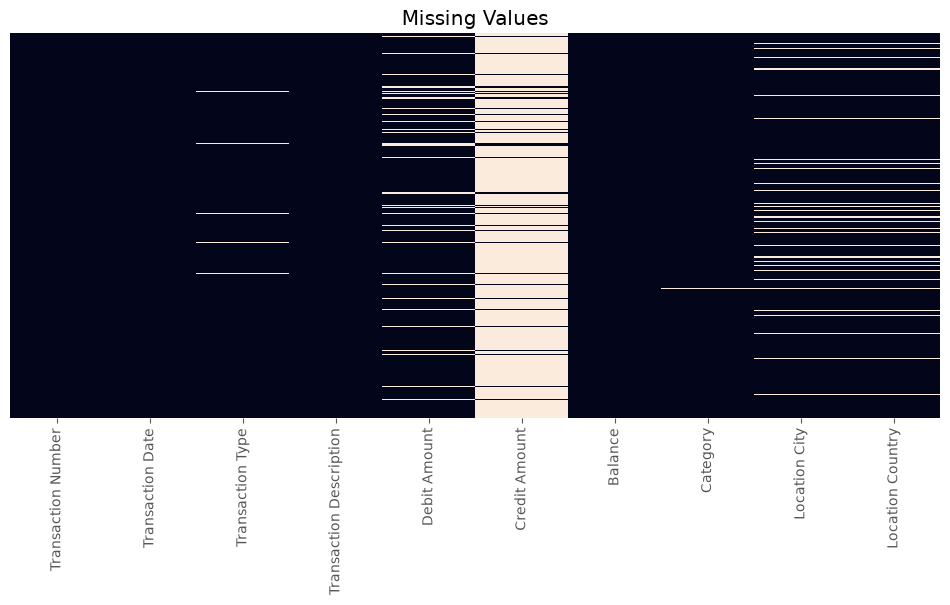

In [12]:
plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values")
plt.show()

Duplicate Records

In [13]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


Data Types

In [14]:
df.dtypes

Transaction Number           int64
Transaction Date            object
Transaction Type               str
Transaction Description     object
Debit Amount               float64
Credit Amount              float64
Balance                    float64
Category                       str
Location City                  str
Location Country               str
dtype: object

Unique Values

In [15]:
unique = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})

unique

,Unique Values,Data Type
Transaction Number,6567,int64
Transaction Date,1660,object
Transaction Type,13,str
Transaction Description,908,object
Debit Amount,2035,float64
Credit Amount,267,float64
Balance,6507,float64
Category,30,str
Location City,58,str
Location Country,16,str


Numerical Feats

In [16]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['Transaction Number', 'Debit Amount', 'Credit Amount', 'Balance'], dtype='str')

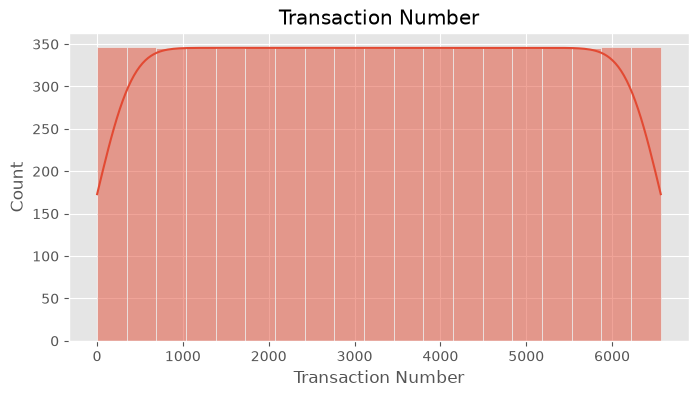

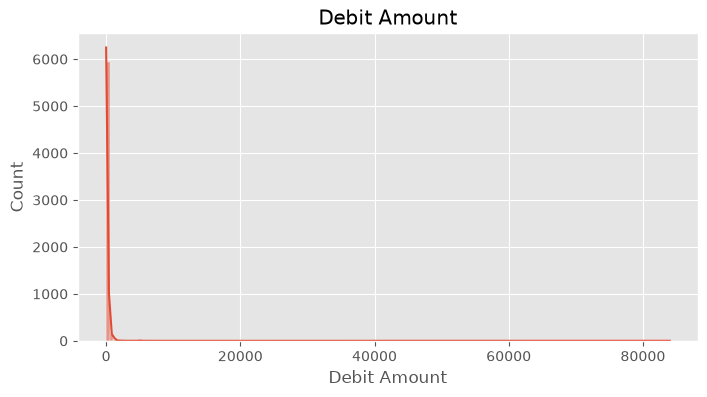

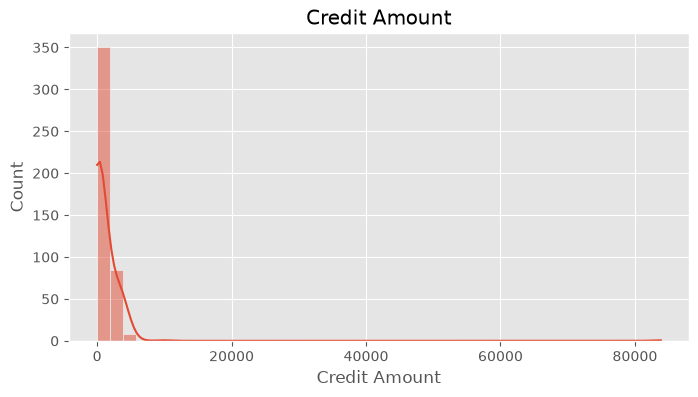

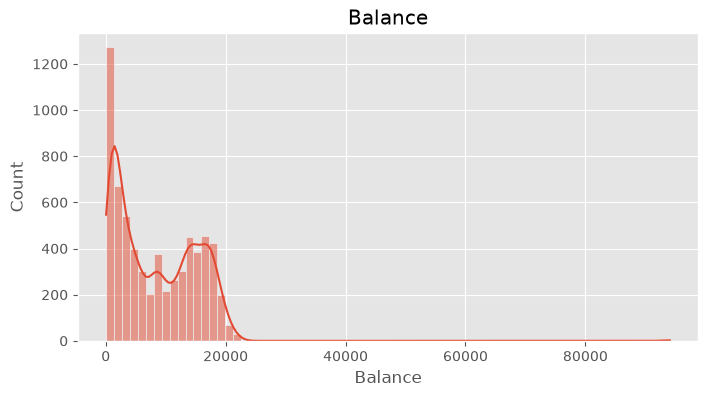

In [17]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

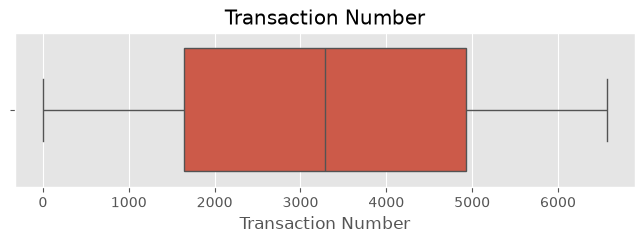

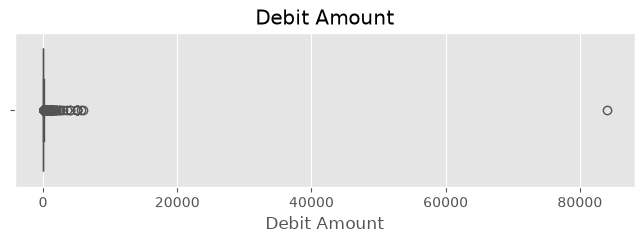

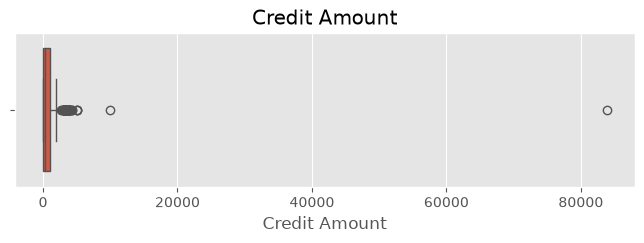

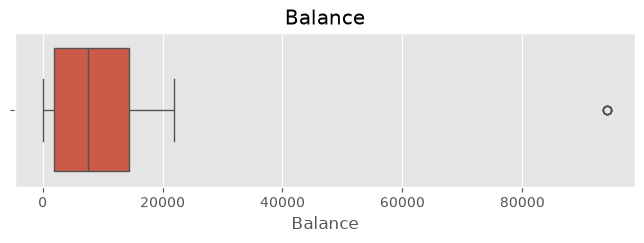

In [18]:
for col in numeric_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

Categorical Features

In [19]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['Transaction Date', 'Transaction Type', 'Transaction Description',
       'Category', 'Location City', 'Location Country'],
      dtype='str')

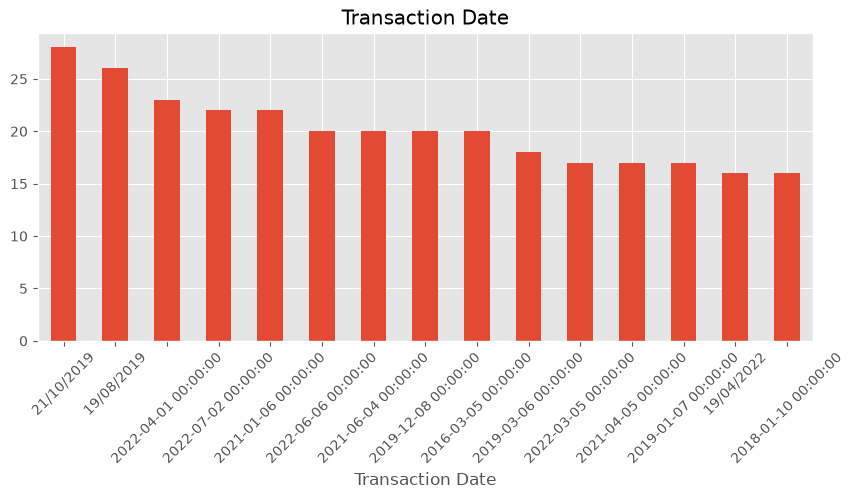

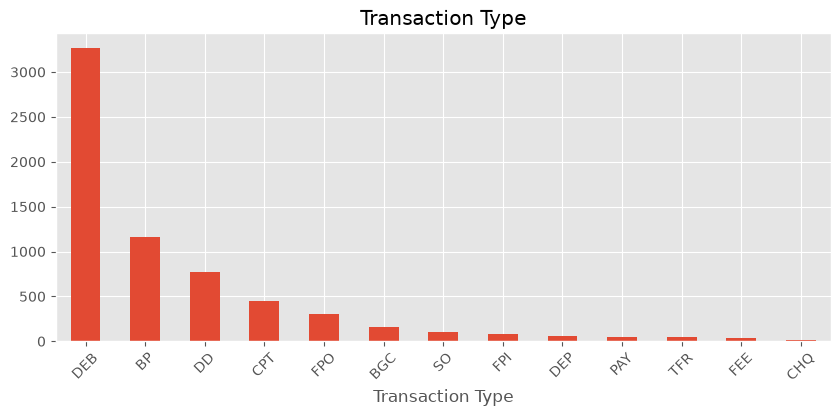

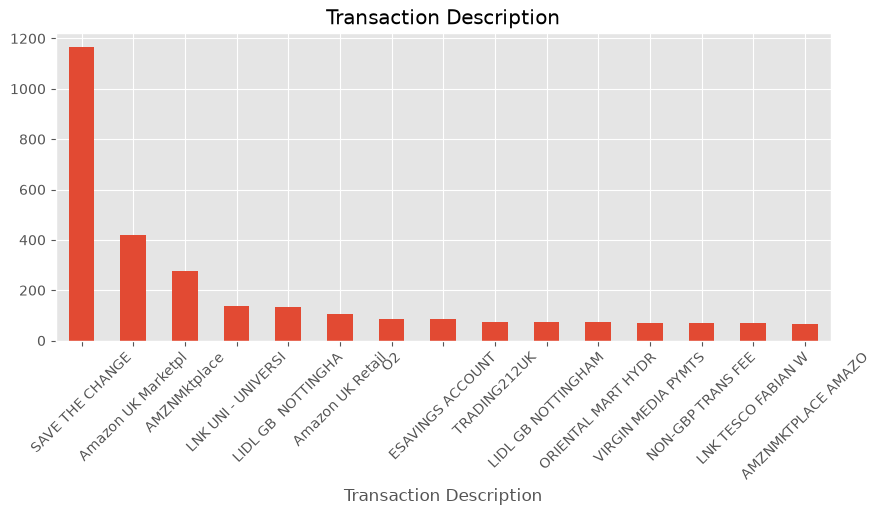

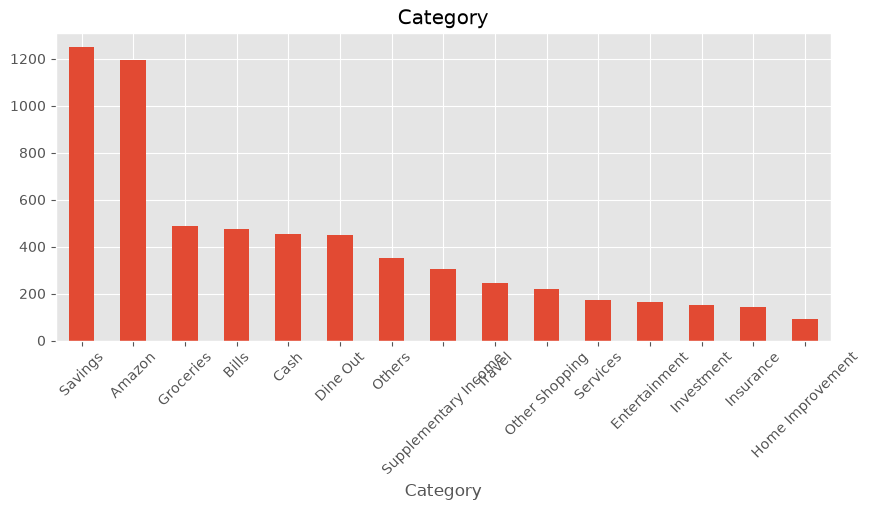

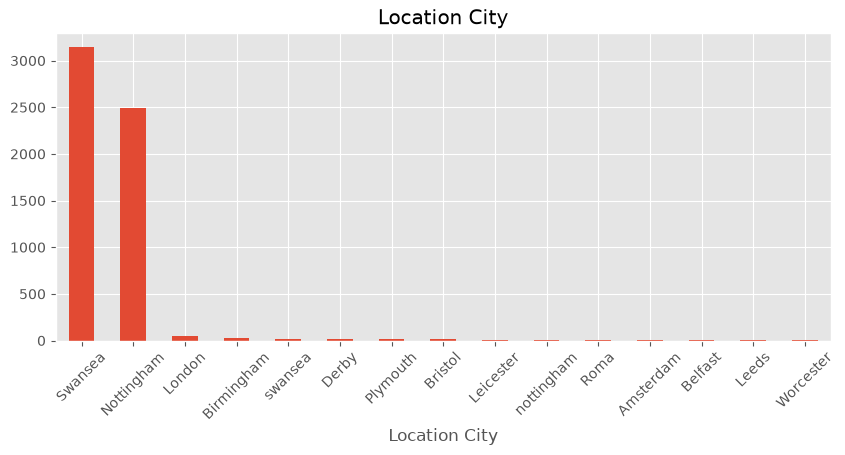

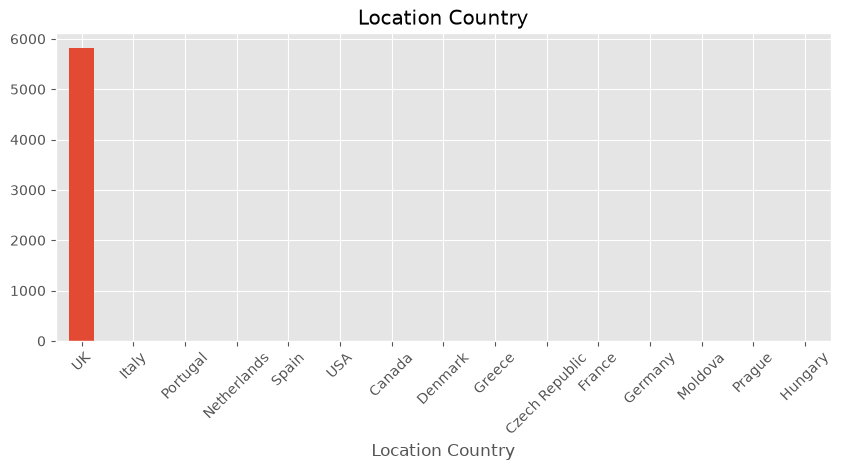

In [20]:
for col in categorical_cols:

    plt.figure(figsize=(10,4))

    (
        df[col]
        .value_counts()
        .head(15)
        .plot(kind="bar")
    )

    plt.title(col)

    plt.xticks(rotation=45)

    plt.show()

11. Correlation Analysis

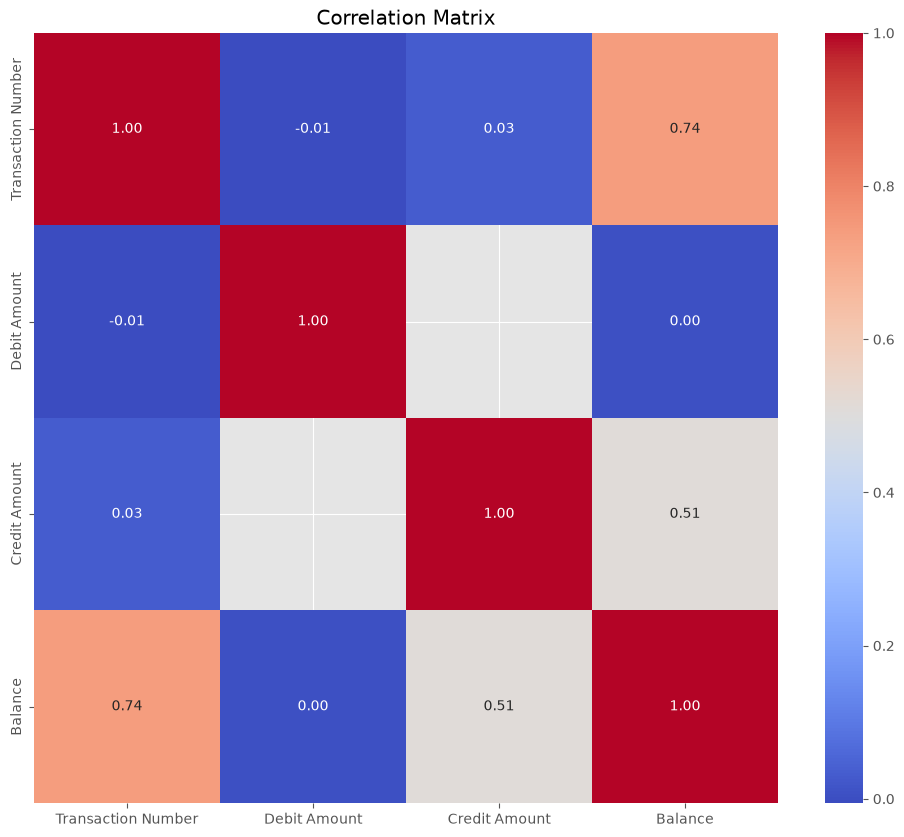

In [21]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Outlier Detection

In [22]:
numeric_cols

Index(['Transaction Number', 'Debit Amount', 'Credit Amount', 'Balance'], dtype='str')

In [23]:
for col in numeric_cols:

    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

Transaction Number: 0 outliers
Debit Amount: 752 outliers
Credit Amount: 93 outliers
Balance: 5 outliers


Initial Findings